In [ ]:
# trying to come up with some script to determine if the thing didn't ignite

In [10]:
# script to debug MC sampling runs
import os
import sys
import copy
import numpy as np
import cantera as ct
import concurrent.futures

import rmgpy.chemkin
import rmgpy.species
import rmgpy.tools.canteramodel
import rmgpy.constants


k_perturbation_matrix = None
G_perturbation_matrix = None


# N=10  # start with this
rmg_species_perturb_indices = [5, 72, 71, 19, 68]
rmg_reaction_perturb_indices = [143, 156, 129, 320, 39]

import matplotlib.pyplot as plt
%matplotlib inline

In [2]:

def perturb_species(species, delta):
    # takes in an RMG species object
    # change the enthalpy offset
    for poly in species.thermo.polynomials:
        new_coeffs = poly.coeffs
        new_coeffs[5] += delta / rmgpy.constants.R
        poly.coeffs = new_coeffs


def perturb_reaction(rxn, delta):  # 0.1 is default
    # takes in an RMG reaction object
    # delta is the ln(k) amount to perturb the A factor
    # delta is a multiplicative factor- units don't matter, yay!
    # does not deepycopy because there's some issues with rmgpy.reactions copying
    if type(rxn.kinetics) == rmgpy.kinetics.chebyshev.Chebyshev:
        rxn.kinetics.coeffs.value_si[0][0] += np.log10(np.exp(delta))
    elif type(rxn.kinetics) in [rmgpy.kinetics.falloff.Troe, rmgpy.kinetics.falloff.ThirdBody, rmgpy.kinetics.falloff.Lindemann]:
        if hasattr(rxn.kinetics, 'arrheniusHigh'):
            rxn.kinetics.arrheniusHigh.A.value *= np.exp(delta)
        if hasattr(rxn.kinetics, 'arrheniusLow'):
            rxn.kinetics.arrheniusLow.A.value *= np.exp(delta)
    elif type(rxn.kinetics) == rmgpy.kinetics.arrhenius.MultiArrhenius:
        for j in range(len(rxn.kinetics.arrhenius)):
            rxn.kinetics.arrhenius[j].A.value *= np.exp(delta)
    elif type(rxn.kinetics) == rmgpy.kinetics.arrhenius.PDepArrhenius:
        for j in range(len(rxn.kinetics.arrhenius)):
            if type(rxn.kinetics.arrhenius[j]) == rmgpy.kinetics.arrhenius.Arrhenius:
                rxn.kinetics.arrhenius[j].A.value *= np.exp(delta)
            elif type(rxn.kinetics.arrhenius[j]) == rmgpy.kinetics.arrhenius.MultiArrhenius:
                for k in range(len(rxn.kinetics.arrhenius[j].arrhenius)):
                    rxn.kinetics.arrhenius[j].arrhenius[k].A.value *= np.exp(delta)
            else:
                raise ValueError(f'weird kinetics {str(rxn.kinetics)}')
    elif type(rxn.kinetics) == rmgpy.kinetics.arrhenius.MultiPDepArrhenius:
        for i in range(len(rxn.kinetics.arrhenius)):
            for j in range(len(rxn.kinetics.arrhenius[i].arrhenius)):
                if type(rxn.kinetics.arrhenius[i].arrhenius[j]) == rmgpy.kinetics.arrhenius.Arrhenius:
                    rxn.kinetics.arrhenius[i].arrhenius[j].A.value *= np.exp(delta)
                elif type(rxn.kinetics.arrhenius[i].arrhenius[j]) == rmgpy.kinetics.arrhenius.MultiArrhenius:
                    for k in range(len(rxn.kinetics.arrhenius[i].arrhenius[j].arrhenius)):
                        rxn.kinetics.arrhenius[i].arrhenius[j].arrhenius[k].A.value *= np.exp(delta)
                else:
                    raise ValueError(f'weird kinetics {str(rxn.kinetics)}')

    else:  # Arrhenius
        rxn.kinetics.A.value *= np.exp(delta)



In [3]:

# Take Reactor Conditions from Table 7 of supplementary info in
# https://doi-org.ezproxy.neu.edu/10.1016/j.combustflame.2010.01.016
def get_delay(gas, T_orig, P_orig, X_orig):
    # function to run a RCM simulation

    atols = [1e-15, 1e-15, 1e-18]
    rtols = [1e-9, 1e-12, 1e-15]
    for attempt_index in range(0, len(atols)):

        t_end = 1.0  # time in seconds
        gas.TPX = T_orig, P_orig, X_orig

        env = ct.Reservoir(ct.Solution('air.yaml'))
        reactor = ct.IdealGasReactor(gas)
        wall = ct.Wall(reactor, env, A=1.0, velocity=0)
        reactor_net = ct.ReactorNet([reactor])
        reactor_net.atol = atols[attempt_index]
        reactor_net.rtol = rtols[attempt_index]

        times = [0]
        T = [reactor.T]
        P = [reactor.thermo.P]
        X = [reactor.thermo.X]  # mol fractions

        MAX_STEPS = 10000
        step_count = 0

        failed = False
        while reactor_net.time < t_end:
            reactor_net.step()

            # try:
            #     reactor_net.step()
            # except ct._cantera.CanteraError:
            #     print(f'Reactor failed to solve on attempt {attempt_index}!')
            #     failed = True
            #     break

            times.append(reactor_net.time)
            T.append(reactor.T)
            P.append(reactor.thermo.P)
            X.append(reactor.thermo.X)

            step_count += 1
            if step_count > MAX_STEPS:
                print(f'Too many steps! Reactor failed to solve on attempt {attempt_index}!')
                # print('!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!')
                failed = True
                break

        if not failed:
            slopes = np.gradient(P, times)
            i = np.argmax(slopes)
            return times[i]
        print(f'That was attempt {attempt_index}. Trying again...')

    print(f'That was attempt {attempt_index}. Ran out of attempts to try.')
    return 0


In [15]:
def run_simulation0(condition_index):
    # Create the cantera model
    job = rmgpy.tools.canteramodel.Cantera(species_list=species_list, reaction_list=reaction_list)
    job.load_model(allow_negative_A=True)
    X = conc_dicts[condition_index]
    delay = get_delay(job.model, experimental_Ts[condition_index], experimental_Ps[condition_index], X)
    return delay


In [11]:

# decide which chunk of the random sampling to handle
sample_start_index = 0

# read in the model
basedir = '/work/westgroup/harris.se/autoscience/fuels/butane/official/butane_20240501/'
chemkin_file = os.path.join(basedir, 'chem_annotated.inp')
dict_file = os.path.join(basedir, 'species_dictionary.txt')
transport = os.path.join(basedir, 'tran.dat')

# load the uncertainty values so we know how much to perturb each parameter
species_uncertainty_file = os.path.join(basedir, 'gao_species_uncertainty.npy')
reaction_uncertainty_file = os.path.join(basedir, 'gao_reaction_uncertainty.npy')
delta_Gs = np.load(species_uncertainty_file)
delta_ks = np.load(reaction_uncertainty_file)

species_list, reaction_list = rmgpy.chemkin.load_chemkin_file(chemkin_file, dictionary_path=dict_file, transport_path=transport)


In [12]:

# experimental conditions copied from subset of # https://doi-org.ezproxy.neu.edu/10.1016/j.combustflame.2010.01.016
conc_dicts = [{
    'O2(2)': 0.2038,
    'butane(1)': 0.03135,
    'Ar': 0.7649
}] * 10
experimental_Ts = [700, 731, 756, 794, 840, 872, 906, 926, 959, 1000]
experimental_Ps = [1013250] * 10

# Map the species to the objects within the Uncertainty class
butane = rmgpy.species.Species(smiles='CCCC')
O2 = rmgpy.species.Species(smiles='[O][O]')
Ar = rmgpy.species.Species(smiles='[Ar]')
mapping = rmgpy.tools.canteramodel.get_rmg_species_from_user_species([butane, O2, Ar], species_list)

# Define the reaction conditions
reactor_type_list = ['IdealGasReactor']
mol_frac_list = [{mapping[butane]: 0.03135, mapping[O2]: 0.2038, mapping[Ar]: 0.7649}]
Tlist = ([700, 731, 756, 794, 840, 872, 906, 926, 959, 1000], 'K')
Plist = ([1013250] * 10, 'bar')
reaction_time_list = ([500], 'ms')


# Generate the perturbations
np.random.seed(400)
N_total = 10000
N_chunk = 1000
G_means = np.zeros(len(species_list))
k_means = np.zeros(len(reaction_list))
delta_Gs_J_per_mol = delta_Gs * 4184
k_perturbation_matrix = np.random.normal(k_means, delta_ks, (N_total, len(reaction_list))).transpose()  # only perturb A Factor
G_perturbation_matrix = np.random.normal(G_means, delta_Gs_J_per_mol, (N_total, len(species_list))).transpose()





In [13]:

perturb_index = 0

condition_index = 2
print(f'T={experimental_Ts[condition_index]}')
delay = run_simulation(condition_index, perturb_index)
print(delay)

print()
print('Base:')
print(0.01296525292766587)

T=756
Running simulation 2 with perturbation 0
Perturbing sp 5 by -10027.075265381645
Perturbing sp 19 by 9559.430877231593
Perturbing sp 68 by -12393.863069625275
Perturbing sp 71 by 2615.9511550863335
Perturbing sp 72 by 31.05625957196252
0.6951828868180001

Base:
0.01296525292766587


2

Loading model...
Doing perturbations...
Running Simulation...
success: 3.4322590648825023e-05
Loading model...
Doing perturbations...
Running Simulation...
success: 0.0031787034643127633
Loading model...
Doing perturbations...
Running Simulation...
success: 1.2538999089362823
Loading model...
Doing perturbations...
Running Simulation...
success: 1.1020908862339134
Loading model...
Doing perturbations...
Running Simulation...
success: 0.4654004323114354
Loading model...
Doing perturbations...
Running Simulation...
success: 0.03270056250837732
Loading model...
Doing perturbations...
Running Simulation...
success: 0.011187510181254913
Loading model...
Doing perturbations...
Running Simulation...
success: 0.018251871143100135
Loading model...
Doing perturbations...
Running Simulation...
success: 0.04486304337443826
Loading model...
Doing perturbations...
Running Simulation...
success: 0.04058007834177875
Loading model...
Doing perturbations...
Running Simulation...
success: 0.0186599062927

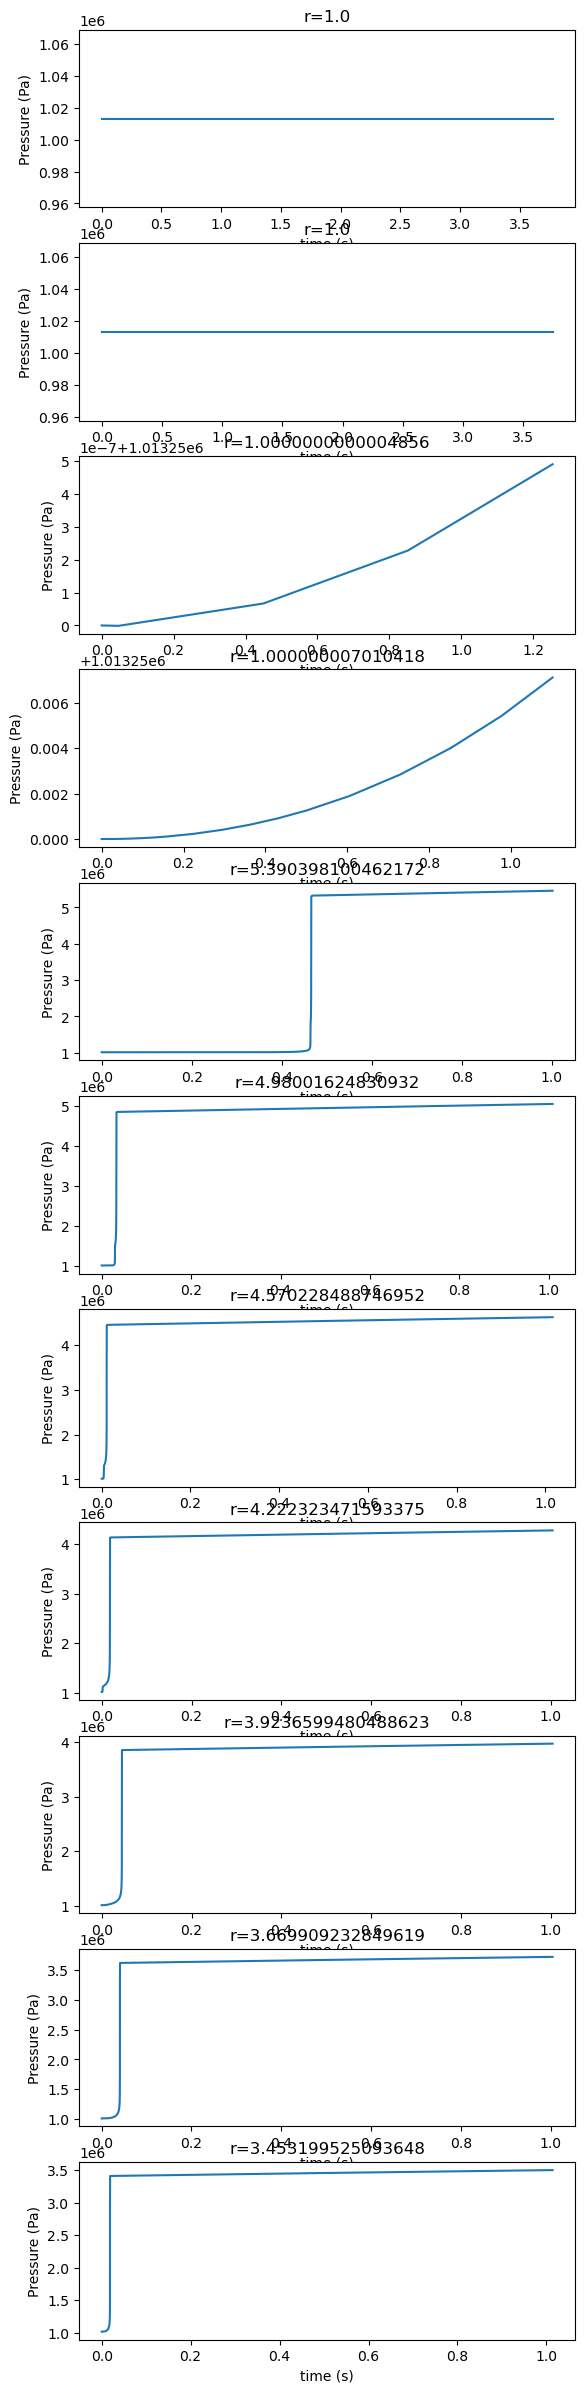

In [67]:
N = 11

condition_index = 8

fig, ax = plt.subplots(N)
fig.set_figheight(30)

for z, T_orig in enumerate(np.linspace(300, 1000, N)):

    print('Loading model...')
    species_list, reaction_list = rmgpy.chemkin.load_chemkin_file(chemkin_file, dictionary_path=dict_file, transport_path=transport)

    print('Doing perturbations...')

    job = rmgpy.tools.canteramodel.Cantera(species_list=species_list, reaction_list=reaction_list)
    job.load_model(allow_negative_A=True)

    X_orig = conc_dicts[condition_index]
    P_orig = experimental_Ps[condition_index]

    gas=job.model

    atols = [1e-15, 1e-15, 1e-18]
    rtols = [1e-9, 1e-12, 1e-15]
    print('Running Simulation...')
    for attempt_index in range(0, len(atols)):

        t_end = 1.0  # time in seconds
        gas.TPX = T_orig, P_orig, X_orig

        env = ct.Reservoir(ct.Solution('air.yaml'))
        reactor = ct.IdealGasReactor(gas)
        wall = ct.Wall(reactor, env, A=1.0, velocity=0)
        reactor_net = ct.ReactorNet([reactor])
        reactor_net.atol = atols[attempt_index]
        reactor_net.rtol = rtols[attempt_index]

        times = [0]
        T = [reactor.T]
        P = [reactor.thermo.P]
        X = [reactor.thermo.X]  # mol fractions

        MAX_STEPS = 10000
        step_count = 0

        failed = False
        while reactor_net.time < t_end:
            reactor_net.step()

            # try:
            #     reactor_net.step()
            # except ct._cantera.CanteraError:
            #     print(f'Reactor failed to solve on attempt {attempt_index}!')
            #     failed = True
            #     break

            times.append(reactor_net.time)
            T.append(reactor.T)
            P.append(reactor.thermo.P)
            X.append(reactor.thermo.X)

            step_count += 1
            if step_count > MAX_STEPS:
                print(f'Too many steps! Reactor failed to solve on attempt {attempt_index}!')
                # print('!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!')
                failed = True
                break

        if not failed:
            slopes = np.gradient(P, times)
            i = np.argmax(slopes)
            print(f'success: {times[i]}')
            break
        print(f'That was attempt {attempt_index}. Trying again...')
    else:
        print(f'That was attempt {attempt_index}. Ran out of attempts to try.')


    plt.sca(ax[z])
    P_ratio = np.max(P) / np.min(P)
    plt.plot(times, P)
    plt.xlabel('time (s)')
    plt.ylabel('Pressure (Pa)')
    plt.title(f'r={P_ratio}')
#     ax = plt.gca()
#     ax.yaxis.get_major_formatter().set_useOffset(False)

1.0000000000026303

In [68]:
np.log10(np.exp(0.1))

0.043429448190325216

In [69]:
np.log10(1.1)

0.04139268515822507

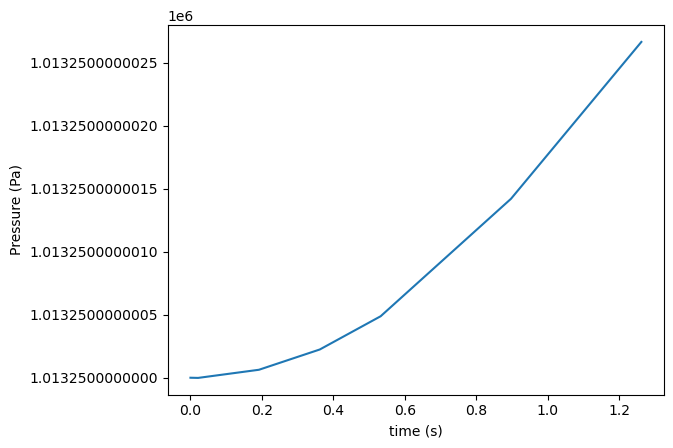

(array([6., 1., 0., 0., 0., 1., 0., 0., 0., 1.]),
 array([1013250.        , 1013250.00000026, 1013250.00000053,
        1013250.0000008 , 1013250.00000106, 1013250.00000133,
        1013250.0000016 , 1013250.00000186, 1013250.00000213,
        1013250.0000024 , 1013250.00000266]),
 <BarContainer object of 10 artists>)

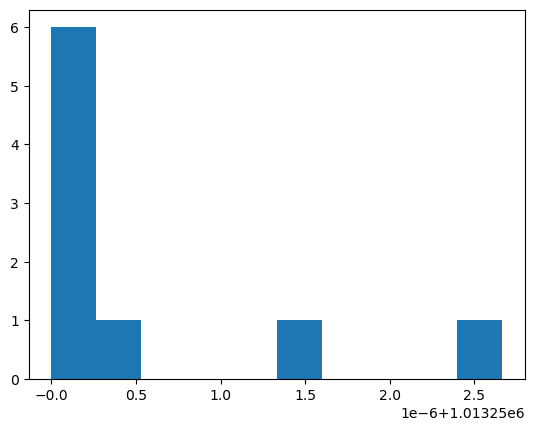

In [61]:
my_step = np.heaviside(np.array(times) - times[int(len(times) / 2.0)], 0)
# plt.plot(times, my_step)
# x = np.convolve(P, my_step)
# plt.plot(x)

plt.hist(P)

# ax = plt.gca()
# ax.xaxis.get_major_formatter().set_useOffset(False)



In [58]:
times

[0,
 2.2625356584265554e-05,
 0.001967335951601713,
 0.021414441901776188,
 0.19175323545369807,
 0.36209202900562,
 0.5324308225575418,
 0.8973529348315574,
 1.262275047105573]

In [57]:
my_step

array([0., 0., 0., 0., 0., 1., 1., 1., 1.])

In [17]:
condition_index = 2
print(f'T={experimental_Ts[condition_index]}')

species_list, reaction_list = rmgpy.chemkin.load_chemkin_file(chemkin_file, dictionary_path=dict_file, transport_path=transport)
run_simulation0(condition_index)

T=756


0.012965253894948762